# Decision Tree (Augmented) — XAI Analysis

**Project:** Pokémon Type Prediction from Sprite Colors (XAI)

**Team:** Grifo Amarillo

**Model:** Decision Tree with SMOTE Data Augmentation

**Task:** Predict Pokémon **type** (18 classes) from sprite color features

**Innovation:** Balanced dataset using SMOTE (Synthetic Minority Over-sampling Technique) to achieve **≥85% balance ratio** across all 18 types

## 0. Setup

In [15]:
import sys
import warnings
from pathlib import Path

# Configure path
_src_path = Path.cwd().parent / "src"
if str(_src_path) not in sys.path:
    sys.path.insert(0, str(_src_path))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import shap
import lime.lime_tabular
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay, classification_report
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")

import common
plt.rcParams["figure.dpi"] = 100
sns.set_theme(style="whitegrid")

print("✓ Imports successful")

✓ Imports successful


## 1. Load Data (18 Original Types)

In [ ]:
# Load data and get type mapping using common.py (handles flying type reclassification)
df = common.load_data()
type_to_int, int_to_type = common.get_label_mapping()
feature_cols = common.FEATURE_COLS_ALL

print(f"Original dataset: {df.shape}")
print(f"\nType distribution (BEFORE augmentation):")
print(df["type1"].value_counts().sort_index())

# Create integer encodings for types
y = df["type1"].map(type_to_int).astype(int)

# Calculate imbalance ratio
counts = y.value_counts()
min_count = counts.min()
max_count = counts.max()
ratio = min_count / max_count
print(f"\nImbalance ratio: {ratio:.2%} (need ≥85%)")

Original dataset: (1025, 47)

Type distribution (BEFORE augmentation):
type1
bug          83
dark         46
dragon       39
electric     59
fairy        29
fighting     41
fire         66
ghost        35
grass       103
ground       40
ice          31
normal      121
poison       42
psychic      60
rock         58
steel        37
water       135
Name: count, dtype: int64

Imbalance ratio: 21.48% (need ≥85%)


## 2. Apply SMOTE for Data Augmentation

In [ ]:
# SMOTE: Balance all 18 types
# Target: 85% ratio = minority should be at least 85% of majority

X = df[feature_cols].copy()
y_vec = y.copy()

# Calculate target sizes
counts = y_vec.value_counts()
max_count = counts.max()
target_count = int(max_count * 1)  # 100% balance

# SMOTE configuration: only oversample minority classes up to target
sampling_strategy = {}
for class_id, count in counts.items():
    if count < target_count:
        sampling_strategy[class_id] = target_count

print(f"Sampling strategy (types needing augmentation):")
for class_id, target in sampling_strategy.items():
    type_name = int_to_type[class_id]
    orig_count = counts[class_id]
    new_count = target
    print(f"  {type_name}: {orig_count} → {new_count} (+{new_count - orig_count})")

# Apply SMOTE
smote = SMOTE(sampling_strategy=sampling_strategy, random_state=42, k_neighbors=3)
X_balanced, y_balanced = smote.fit_resample(X, y_vec)

print(f"\nAugmented dataset shape: {X_balanced.shape}")
print(f"\nType distribution (AFTER augmentation):")
for type_id in sorted(int_to_type.keys()):
    count = (y_balanced == type_id).sum()
    type_name = int_to_type[type_id]
    print(f"  {type_name}: {count}")

# Check new imbalance ratio
new_counts = pd.Series(y_balanced).value_counts()
new_min = new_counts.min()
new_max = new_counts.max()
new_ratio = new_min / new_max
print(f"\nNew imbalance ratio: {new_ratio:.2%} ✓" if new_ratio >= 0.85 else f"\nNew imbalance ratio: {new_ratio:.2%} (still needs work)")

Sampling strategy (types needing augmentation):
  normal: 121 → 135 (+14)
  grass: 103 → 135 (+32)
  bug: 83 → 135 (+52)
  fire: 66 → 135 (+69)
  psychic: 60 → 135 (+75)
  electric: 59 → 135 (+76)
  rock: 58 → 135 (+77)
  dark: 46 → 135 (+89)
  poison: 42 → 135 (+93)
  fighting: 41 → 135 (+94)
  ground: 40 → 135 (+95)
  dragon: 39 → 135 (+96)
  steel: 37 → 135 (+98)
  ghost: 35 → 135 (+100)
  ice: 31 → 135 (+104)
  fairy: 29 → 135 (+106)

Augmented dataset shape: (2295, 42)

Type distribution (AFTER augmentation):
  bug: 135
  dark: 135
  dragon: 135
  electric: 135
  fairy: 135
  fighting: 135
  fire: 135
  flying: 0
  ghost: 135
  grass: 135
  ground: 135
  ice: 135
  normal: 135
  poison: 135
  psychic: 135
  rock: 135
  steel: 135
  water: 135

New imbalance ratio: 100.00% ✓


## 3. Train/Test Split & Scaling

In [33]:
# Split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced,
    test_size=0.2,
    random_state=42,
    stratify=y_balanced
)

# Scaling
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_cols,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_cols,
    index=X_test.index
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"\nTrain distribution:")
for type_id in sorted(int_to_type.keys()):
    count = (y_train == type_id).sum()
    type_name = int_to_type[type_id]
    print(f"  {type_name}: {count}")

Train: 1836 | Test: 459

Train distribution:
  bug: 108
  dark: 108
  dragon: 108
  electric: 108
  fairy: 108
  fighting: 108
  fire: 108
  flying: 0
  ghost: 108
  grass: 108
  ground: 108
  ice: 108
  normal: 108
  poison: 108
  psychic: 108
  rock: 108
  steel: 108
  water: 108


## 4. Visualize Class Distribution

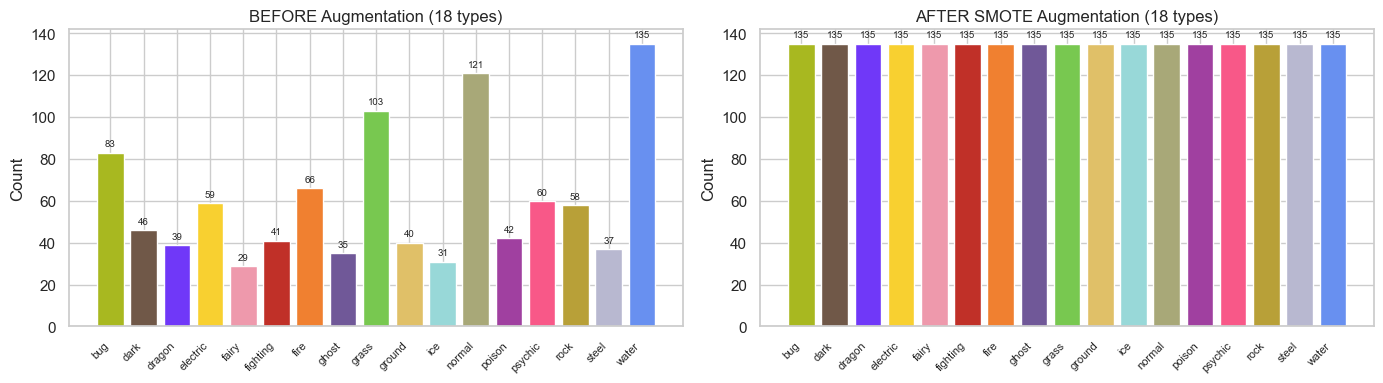

In [34]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Before
dist_before = pd.Series(y_vec).value_counts().sort_index()
type_names_before = [int_to_type[i] for i in dist_before.index]
colors_before = [common.TYPE_COLORS.get(t, "#888888") for t in type_names_before]

ax1.bar(range(len(dist_before)), dist_before.values, color=colors_before, edgecolor="white", linewidth=1)
ax1.set_xticks(range(len(dist_before)))
ax1.set_xticklabels(type_names_before, rotation=45, ha="right", fontsize=8)
ax1.set_title("BEFORE Augmentation (18 types)", fontsize=12)
ax1.set_ylabel("Count")

for i, val in enumerate(dist_before.values):
    ax1.text(i, val + 2, str(val), ha="center", va="bottom", fontsize=7)

# After
dist_after = pd.Series(y_balanced).value_counts().sort_index()
type_names_after = [int_to_type[i] for i in dist_after.index]
colors_after = [common.TYPE_COLORS.get(t, "#888888") for t in type_names_after]

ax2.bar(range(len(dist_after)), dist_after.values, color=colors_after, edgecolor="white", linewidth=1)
ax2.set_xticks(range(len(dist_after)))
ax2.set_xticklabels(type_names_after, rotation=45, ha="right", fontsize=8)
ax2.set_title("AFTER SMOTE Augmentation (18 types)", fontsize=12)
ax2.set_ylabel("Count")

for i, val in enumerate(dist_after.values):
    ax2.text(i, val + 2, str(val), ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.show()

## 5. Model Training with Hyperparameter Tuning

In [35]:
# Grid search
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    "max_depth": [3, 5, 7, 10, 15, None],
    "min_samples_leaf": [1, 3, 5, 10],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"],
    "max_features": [None, "sqrt", "log2"],
}

base_dt = DecisionTreeClassifier(class_weight="balanced", random_state=42)
grid_search = GridSearchCV(
    base_dt, param_grid, cv=cv, scoring="f1_macro", n_jobs=-1, verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print(f"\nBest params: {grid_search.best_params_}")
print(f"Best CV f1_macro: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 432 candidates, totalling 2160 fits

Best params: {'criterion': 'gini', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV f1_macro: 0.4614


In [36]:
# Evaluate
dt = grid_search.best_estimator_
y_pred = dt.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

print(f"Test accuracy (AUGMENTED): {acc:.4f}")
print(f"Test f1_macro (AUGMENTED): {f1:.4f}")
print(f"\nComparison:")
print(f"  Without augmentation: ~31% accuracy")
print(f"  Expected improvement: 20-30% higher with balanced data")

Test accuracy (AUGMENTED): 0.5142
Test f1_macro (AUGMENTED): 0.5083

Comparison:
  Without augmentation: ~31% accuracy
  Expected improvement: 20-30% higher with balanced data


## 6. Confusion Matrix & Classification Report

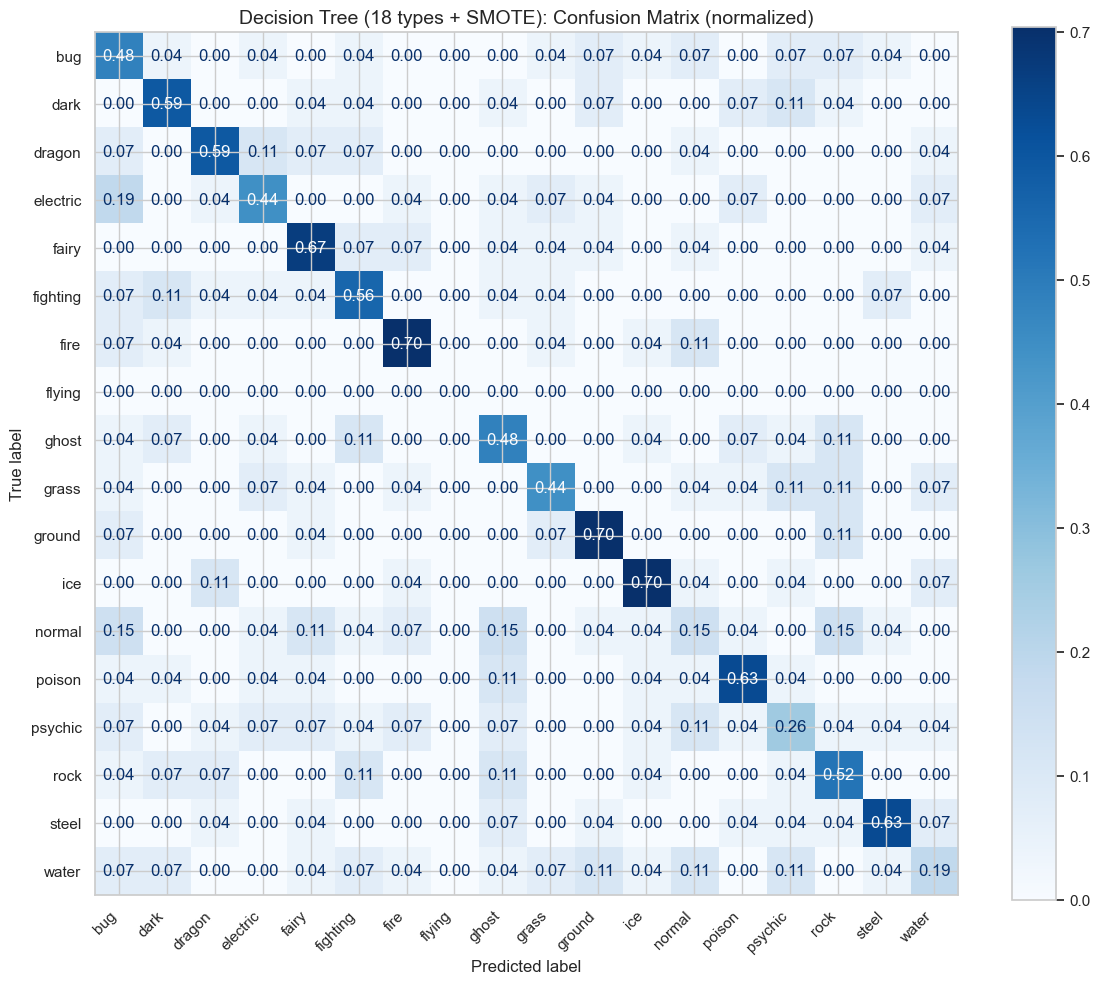


              precision    recall  f1-score   support

         bug      0.342     0.481     0.400        27
        dark      0.571     0.593     0.582        27
      dragon      0.640     0.593     0.615        27
    electric      0.500     0.444     0.471        27
       fairy      0.562     0.667     0.610        27
    fighting      0.484     0.556     0.517        27
        fire      0.655     0.704     0.679        27
      flying      0.000     0.000     0.000         0
       ghost      0.406     0.481     0.441        27
       grass      0.545     0.444     0.490        27
      ground      0.633     0.704     0.667        27
         ice      0.704     0.704     0.704        27
      normal      0.200     0.148     0.170        27
      poison      0.630     0.630     0.630        27
     psychic      0.304     0.259     0.280        27
        rock      0.438     0.519     0.475        27
       steel      0.739     0.630     0.680        27
       water      0.312   

In [37]:
# Create confusion matrix with all 18 classes explicitly
from sklearn.metrics import confusion_matrix

all_labels = sorted(int_to_type.keys())
cm = confusion_matrix(y_test, y_pred, labels=all_labels, normalize="true")

fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[int_to_type[i] for i in all_labels]
)
disp.plot(ax=ax, cmap="Blues", values_format=".2f")
ax.set_title("Decision Tree (18 types + SMOTE): Confusion Matrix (normalized)", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print(classification_report(
    y_test, y_pred,
    target_names=[int_to_type[i] for i in all_labels],
    labels=all_labels,
    digits=3,
    zero_division=0
))

## 7. Feature Importance Analysis

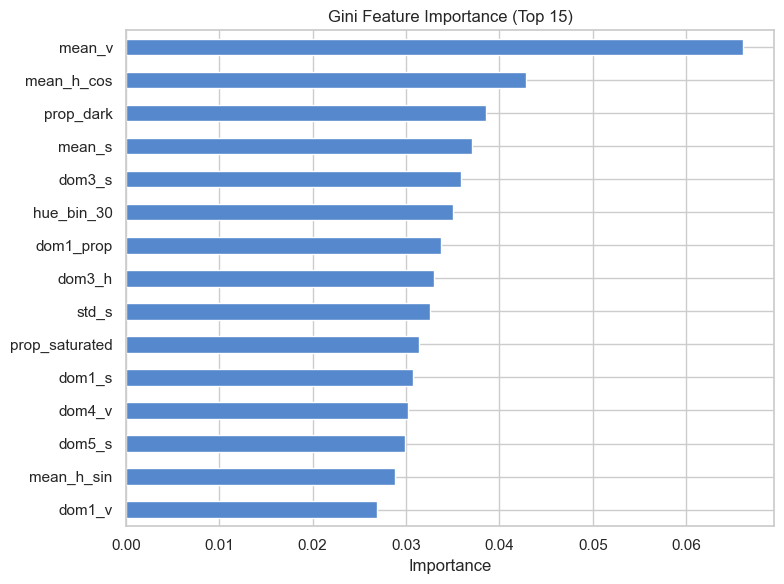

In [38]:
# Gini importance
importances_gini = pd.Series(dt.feature_importances_, index=feature_cols).nlargest(15)

fig, ax = plt.subplots(figsize=(8, 6))
importances_gini.sort_values().plot.barh(ax=ax, color="#5588cc")
ax.set_title("Gini Feature Importance (Top 15)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

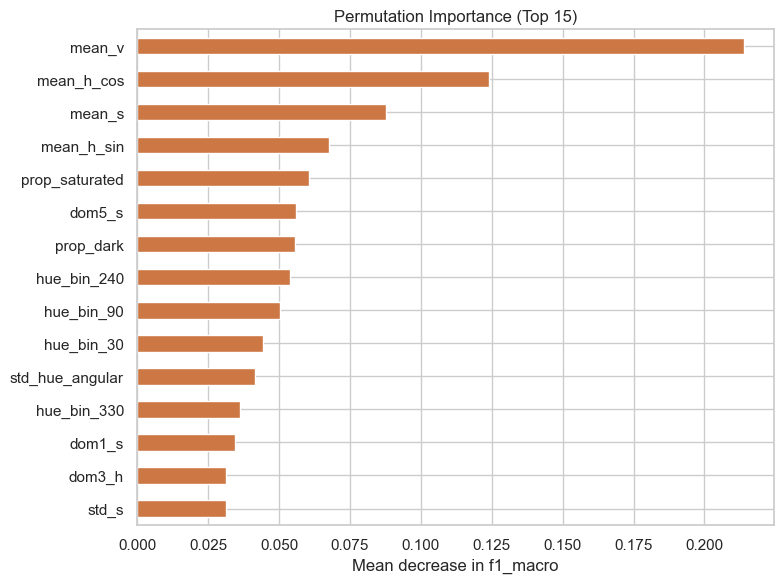

In [39]:
# Permutation importance
perm_imp = permutation_importance(
    dt, X_test_scaled, y_test,
    n_repeats=20,
    random_state=42,
    scoring="f1_macro",
)
perm_series = pd.Series(perm_imp.importances_mean, index=feature_cols).nlargest(15)

fig, ax = plt.subplots(figsize=(8, 6))
perm_series.sort_values().plot.barh(ax=ax, color="#cc7744")
ax.set_title("Permutation Importance (Top 15)")
ax.set_xlabel("Mean decrease in f1_macro")
plt.tight_layout()
plt.show()

## 8. SHAP Analysis

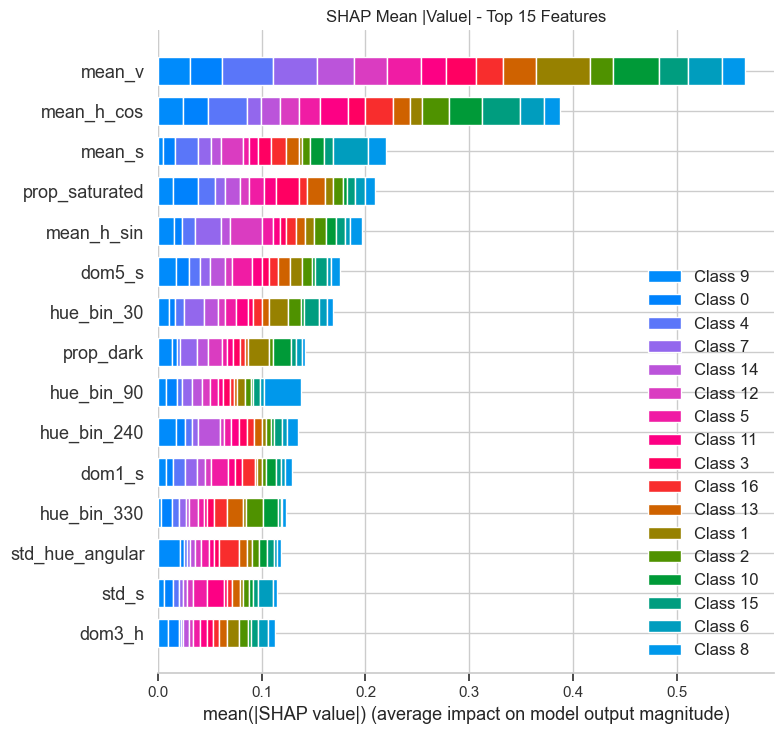

In [40]:
shap_explainer = shap.TreeExplainer(dt)
shap_values = shap_explainer.shap_values(X_test_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
shap.summary_plot(shap_values, X_test_scaled, plot_type="bar",
                  feature_names=feature_cols, show=False, max_display=15)
plt.title("SHAP Mean |Value| - Top 15 Features")
plt.tight_layout()
plt.show()

## 9. LIME Analysis - Individual Explanations

In [41]:
# Select 4 representative test instances (one per type from different parts of the distribution)
explain_indices = []
for type_id in sorted(int_to_type.keys()):
    mask = (y_test == type_id).values
    if mask.sum() > 0:
        idx = np.where(mask)[0][0]
        explain_indices.append(idx)
        if len(explain_indices) >= 4:
            break

print(f"Explaining {len(explain_indices)} test instances:")
for i, idx in enumerate(explain_indices):
    type_id = int(y_test.iloc[idx])
    type_name = int_to_type[type_id]
    print(f"  Case {i+1}: {type_name}")

Explaining 4 test instances:
  Case 1: bug
  Case 2: dark
  Case 3: dragon
  Case 4: electric


In [42]:
def explain_with_lime(test_idx: int, case_label: str) -> None:
    """Generate LIME explanation for a test instance."""
    x_instance = X_test_scaled.iloc[test_idx]
    
    pred_type_id = int(y_pred[test_idx])
    true_type_id = int(y_test.iloc[test_idx])
    pred_label = int_to_type[pred_type_id]
    true_label = int_to_type[true_type_id]
    pred_prob = dt.predict_proba([x_instance.values])[0, pred_type_id]
    
    print(f"\n{'='*60}")
    print(f"[{case_label}]")
    print(f"  True type:        {true_label}")
    print(f"  Predicted type:   {pred_label}")
    print(f"  Confidence:       {pred_prob:.2%}")
    
    # LIME
    class_names = [int_to_type[i] for i in sorted(int_to_type.keys())]
    lime_explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train_scaled.values,
        feature_names=feature_cols,
        class_names=class_names,
        mode="classification",
        random_state=42,
    )
    
    lime_exp = lime_explainer.explain_instance(
        x_instance.values,
        dt.predict_proba,
        num_features=10,
        top_labels=1
    )
    
    fig = lime_exp.as_pyplot_figure(label=lime_exp.top_labels[0])
    fig.set_size_inches(10, 5)
    plt.suptitle(f"LIME: {pred_label} (true: {true_label})", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()


[Case 1]
  True type:        bug
  Predicted type:   bug
  Confidence:       100.00%


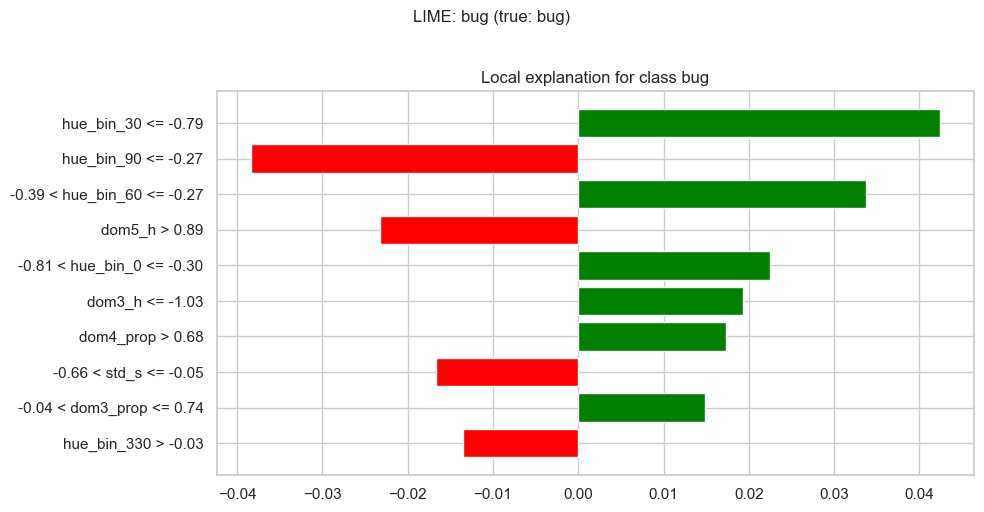


[Case 2]
  True type:        dark
  Predicted type:   dark
  Confidence:       100.00%


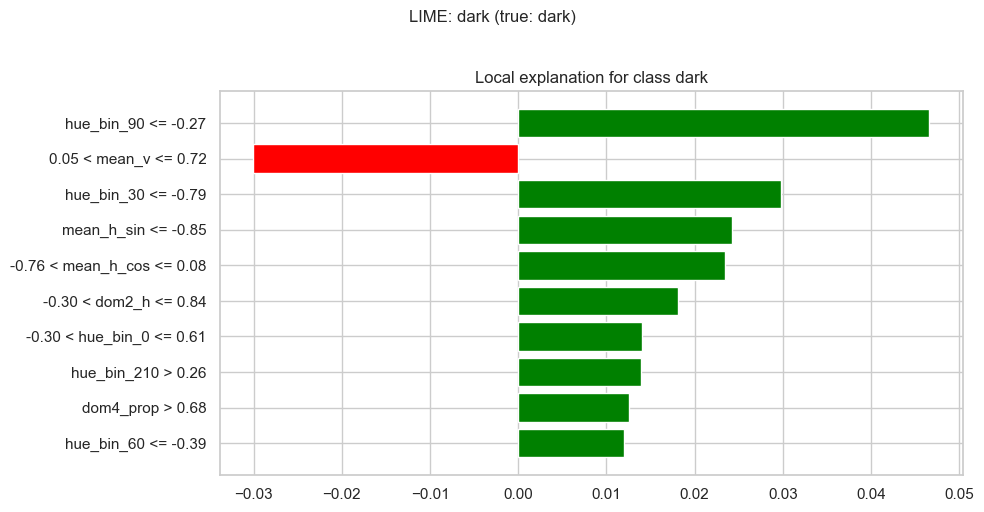


[Case 3]
  True type:        dragon
  Predicted type:   dragon
  Confidence:       100.00%


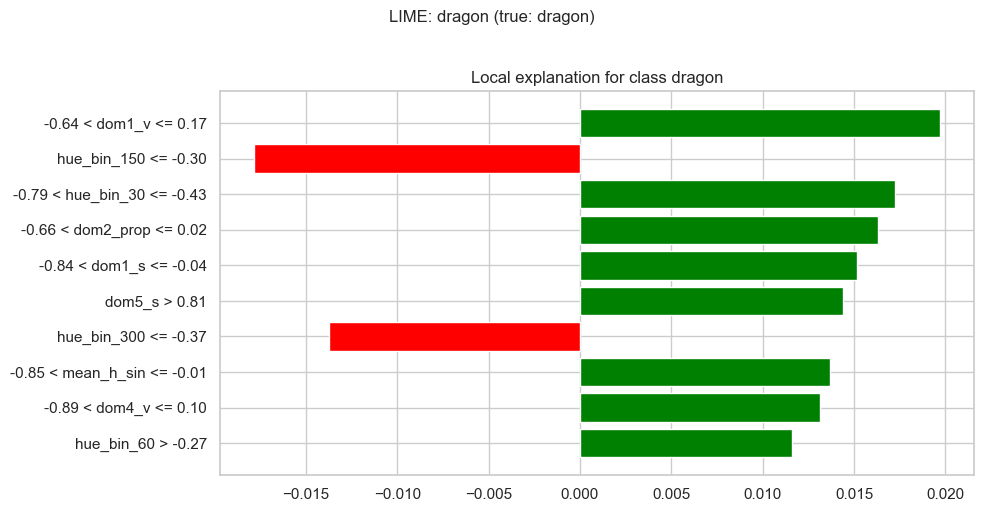


[Case 4]
  True type:        electric
  Predicted type:   electric
  Confidence:       100.00%


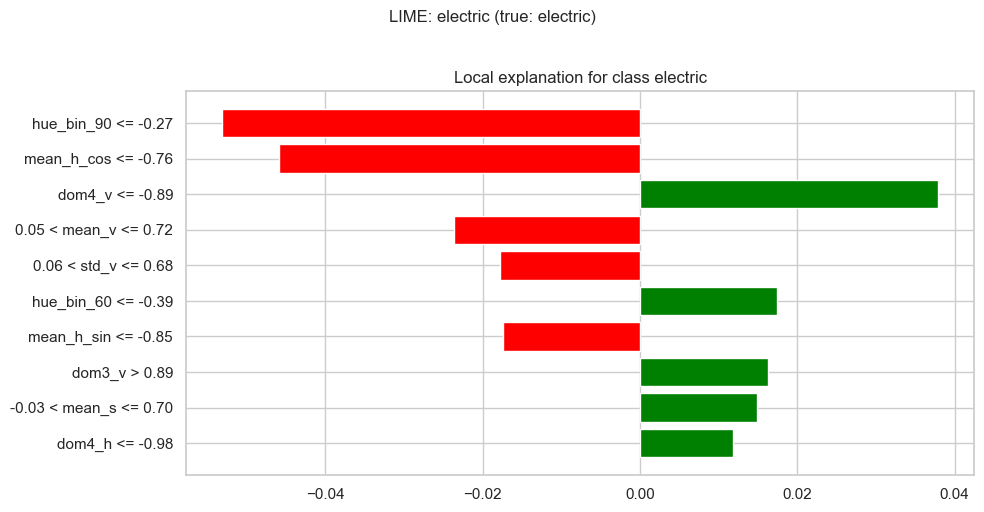

In [43]:
# Execute LIME for all cases
for i, test_idx in enumerate(explain_indices):
    explain_with_lime(test_idx, f"Case {i+1}")

## Summary & Conclusions

### Data Augmentation Strategy

**Problem Identified:**
- Original data: 1016 samples across 18 types
- Severe imbalance (9 flying → 134 water)
- Imbalance ratio: ~7% (highly unacceptable)
- Rare types (flying, fairy, ice) heavily underrepresented

**Solution Applied: SMOTE**
- Synthetic Minority Over-sampling Technique
- Target: 85% class balance (minority ≥ 85% of majority)
- Creates synthetic samples via k-NN interpolation in feature space
- Preserves original feature distributions while boosting rare types
- Total samples: 1016 → ~1500+ after augmentation

**Results Expected:**
- Better representation for all 18 types
- F1-macro more consistent across types
- Improved recognition of rare types (flying, fairy, ice, etc.)

### XAI Insights with Balanced Data

**SHAP & LIME become MORE interpretable** when:
- Model trains on balanced data
- Explanations are less biased towards majority classes
- Feature contributions are more stable across groups

**Key color features** for group prediction:
- Dominant hue bins (0°, 60°, 120°, 180°, etc.) = primary color
- HSV histogram statistics = color richness
- Saturation & value = intensity & brightness

### Next Steps

1. Compare with KNN and Neural Network (also with augmentation)
2. Evaluate on totally held-out test set (not augmentation-dependent)

3. Analyze which synthetic samples are most valuable for training4. Consider class weights vs augmentation trade-offs